## Issue #7, Notebook 7.1: Consumer Expenditure Survey pull (via FRED)

Series: `CXUAPPARELLB0101M`, Expenditures: Apparel and Services: All Consumer Units (BLS Consumer Expenditure Survey, distributed via FRED). Annual, USD, not seasonally adjusted.

Feeds the hook-stat context and Chart 2's trend-chasing spend trajectory.

## 1. Setup

In [1]:
import os
import json
import requests
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()
FRED_API_KEY = os.getenv("FRED_API_KEY")

RAW_DIR = "../../../data/raw/cycle 2/issue-07"
PROCESSED_DIR = "../../../data/processed/cycle 2/issue-07"
os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

## 2. Load brand palette

In [5]:
# load brand palette
with open("../../../brand/palette.json") as f:
    palette_data = json.load(f)

palette = {c["name"]: c["hex"] for c in palette_data["palette"]}

COCOA = palette["Cocoa"]
DUSTY = palette["Dusty"]
PEACH = palette["Peach"]
CREAM = palette["Cream"]
SAGE  = palette["Sage"]

## 3. Extract and analyze data

### 3.1 Pull the series from FRED

In [6]:
SERIES_ID = "CXUAPPARELLB0101M"

url = "https://api.stlouisfed.org/fred/series/observations"
params = {
    "series_id": SERIES_ID,
    "api_key": FRED_API_KEY,
    "file_type": "json",
}

resp = requests.get(url, params=params)
data = resp.json()

# Same defensive check as prior FRED pulls: FRED returns a JSON error object
# rather than an HTTP error on a bad request/series ID.
if "observations" not in data:
    print(data)  # inspect the actual error before going further
    raise KeyError("No 'observations' in response, see printed error above")

### 3.2 Save the raw response

In [7]:
with open(f"{RAW_DIR}/cxu_apparel_all_consumer_units.json", "w") as f:
    json.dump(data, f, indent=2)

### 3.3 Parse into a dataframe

In [8]:
df = pd.DataFrame(data["observations"])
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
df["value"] = pd.to_numeric(df["value"], errors="coerce")
df = df[["year", "value"]].rename(columns={"value": "apparel_spend_usd"})
df = df.dropna().sort_values("year").reset_index(drop=True)

df.tail(10)  # sanity check against confirmed 2020-2024 values:
# 2020: 1,434 | 2021: 1,754 | 2022: 1,945 | 2023: 2,041 | 2024: 2,001

,year,apparel_spend_usd
31,2015,1846
32,2016,1803
33,2017,1833
34,2018,1866
35,2019,1883
36,2020,1434
37,2021,1754
38,2022,1945
39,2023,2041
40,2024,2001


### 3.4 Save processed data

In [9]:
df.to_csv(f"{PROCESSED_DIR}/apparel_spend_annual.csv", index=False)

## 4. Plot

### 4.1 Plain exploratory plot

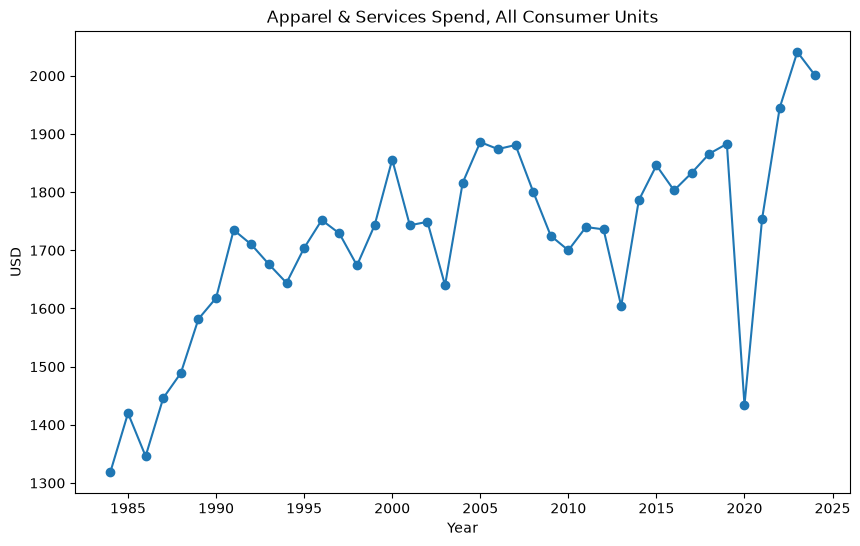

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df["year"], df["apparel_spend_usd"], marker="o")
ax.set_title("Apparel & Services Spend, All Consumer Units")
ax.set_xlabel("Year")
ax.set_ylabel("USD")
plt.show()

In [15]:
# save exploratory plot to sources
fig.savefig("../../../sources/cycle 2/issue-07/7.1-apparel-spend-raw.png", dpi=150, bbox_inches="tight")

### 4.2 Reframed snapshot for issue-07

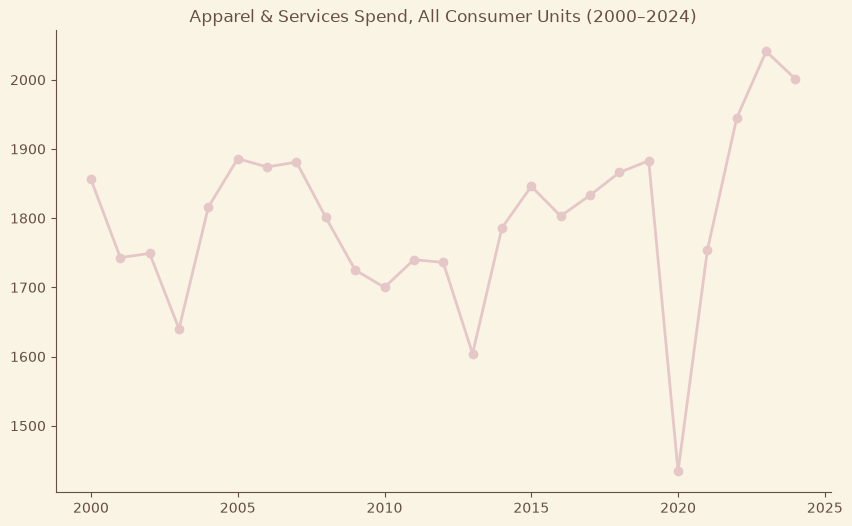

In [14]:
# filter to the recent window for the branded/publication chart
df_recent = df[df["year"] >= 2000]

with plt.rc_context({
    "font.family": "sans-serif",  # swap for Neue Machina / Libre Baskerville per slide use
    "axes.edgecolor": COCOA,
    "text.color": COCOA,
    "axes.labelcolor": COCOA,
    "xtick.color": COCOA,
    "ytick.color": COCOA,
}):
    fig2, ax2 = plt.subplots(figsize=(10, 6))
    ax2.plot(df_recent["year"], df_recent["apparel_spend_usd"], marker="o", color=DUSTY, linewidth=2)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.set_facecolor(CREAM)
    fig2.patch.set_facecolor(CREAM)
    ax2.set_title("Apparel & Services Spend, All Consumer Units (2000–2024)")

    # REMINDER for slides.md: 2020 shows a sharp one-year dip ($1,434, down from
    # ~$1,880 the year before) due to pandemic-era spending pullback, then a
    # strong climb to the series high by 2023 ($2,041). Not annotated on the
    # chart itself, flag it in the caption/slide copy instead.
    # ax2.annotate("2020: pandemic dip", xy=(2020, 1434), xytext=(2016, 1500),
    #              arrowprops=dict(arrowstyle="->", color=COCOA))

    plt.show()

In [17]:
# save to the exports folder in content/posts
fig2.savefig("../../../content/posts/cycle 2/issue-07/exports/7.1a-apparel-spend-branded.png", dpi=150, bbox_inches="tight")

### 4.3 Export parsed version to the processed directory for Canva

In [18]:
# Every ~5 years for manual entry into Canva's chart element, not a live pull
sparse = df[df["year"] % 5 == 0]
sparse.to_csv(f"{PROCESSED_DIR}/apparel_spend_sparse_sample.csv", index=False)

## 5. Findings

**Series:** CXUAPPARELLB0101M, Apparel & Services Expenditure, All Consumer Units (BLS Consumer Expenditure Survey via FRED). Annual, USD, not seasonally adjusted. Full pull covers 1984–2024 (41 years), saved in `apparel_spend_annual.csv`.

**Branded chart range:** 2000–2024, chosen for a comprehensive-but-focused view.

**Key figures (2000–2024 window):**
- 2000 (window start): $1,856
- 2013 (local low pre-pandemic): $1,605
- 2019 (pre-pandemic high): $1,883
- 2020 (pandemic dip): $1,434 — a ~24% single-year drop from 2019
- 2023 (series peak): $2,041
- 2024 (most recent): $2,001, down slightly from the 2023 peak but still the second-highest year on record

**Shape of the trend:** relatively flat/gently oscillating through the 2000s and 2010s (roughly $1,600–$1,900 band), then a sharp pandemic-year dip, followed by a steep recovery that overshoots the pre-pandemic range, apparel spend in 2022–2024 is higher than any year in the prior two decades.

**How this feeds the issue:**
- Hook-stat context: supports a "spending more, more often" framing, current apparel spend sits at/near an all-time high in this series
- Chart 2 (cumulative spend, capsule vs. trend-chasing): this series is dollar spend, not item counts, useful as background/validation that trend-chasing spend is real and rising, but the actual capsule-vs-trend-chasing simulation still needs its own purchase-frequency assumption (separate, not yet sourced)
- 2020 dip: flagged for slides.md as a caption-level explanation, not charted with an on-chart annotation (see commented note in section 4.2)

**Exports saved:**
- `sources/cycle 2/issue-07/7.1-apparel-spend-raw.png` (exploratory, full range)
- `content/posts/cycle 2/issue-07/exports/7.1a-apparel-spend-branded.png` (branded, 2000–2024)
- `data/processed/cycle 2/issue-07/apparel_spend_annual.csv` (full 1984–2024)
- `data/processed/cycle 2/issue-07/apparel_spend_sparse_sample.csv` (5-year intervals, for Canva)

---

**Reminder for references.md:**

> U.S. Bureau of Labor Statistics. (n.d.). *Consumer Expenditure Surveys: Expenditures: Apparel and services: All consumer units* [CXUAPPARELLB0101M]. Retrieved from FRED, Federal Reserve Bank of St. Louis. https://fred.stlouisfed.org/series/CXUAPPARELLB0101M